## Image Caption Generation

### Motivation

> 1. Understand the principles of text pre-processing and vocabulary building.
> 2. Gain experience working with an image to text model.
> 3. Use and compare two different text similarity metrics for evaluating an image to text model, and understand evaluation challenges.

### Setup and resources

Having a GPU will speed up the image feature extraction process. You can use Google Colab to complete this assingment.

Please implement the coursework using Python and PyTorch (i.e., Keras and TensorFlow are **not** accepted).

This coursework will use a subset of the [COCO "Common Objects in Context" dataset](https://cocodataset.org/) for image caption generation. COCO contains 330K images, of 80 object categories, and at least five textual reference captions per image. Our subset consists of 5029 of these images, each of which has five or more different descriptions of the salient entities and activities, and we will refer to it as COCO_5029.

To download the data:

> 1. **Images**: download the zip file "coco_subset_images.zip (812MB)" [here](https://leeds365-my.sharepoint.com/:f:/g/personal/busmnom_leeds_ac_uk/EuAH3b6a4g9IjTNhroLLXPoB6ho6cwxYSNh885ZzrktYZA?e=QGSYpf).
> 2. **Reference captions**: on the COCO [download page](https://cocodataset.org/#download), download the file named "2017 Train/Val annotations (241MB)".
> 3. **Image meta data**: as our set is a subset of full COCO dataset, we have created a CSV file containing relevant meta data for our particular subset of images. You can download it also from Drive, "coco_subset_meta.csv" at the same link as 1.


## Imports

In [58]:
import torch
import torch.nn as nn
from torchvision import transforms
import torchvision.models as models
from torch.utils.data import Dataset
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import os
import numpy as np
from google.colab import drive
drive.mount('/content/drive')
from IPython.display import Image, Markdown, display

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Detect which device (CPU/GPU) to use.

In [59]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


The basic principle of our image-to-text model is as pictured in the diagram below, where an Encoder network encodes the input image as a feature vector by providing the outputs of the last fully-connected layer of a pre-trained CNN (we use [ResNet-152](https://arxiv.org/abs/1512.03385)). This pretrained network has been trained on the complete ImageNet dataset and is thus able to recognise common objects.

These features are then fed into a Decoder network along with the reference captions. As the image feature dimensions are large and sparse, the Decoder network includes a linear layer which downsizes them, followed by a batch normalisation layer to speed up training. Those resulting features, as well as the reference text captions, are passed into a recurrent network (we will use an RNN).

The reference captions used to compute loss are represented as numerical vectors via an embedding layer whose weights are learned during training.

![Encoder Decoder](encoder_decoder_diagramv2022.png)

The Encoder-Decoder network could be coupled and trained end-to-end, without saving features to disk; however, this requires iterating through the entire image training set during training. We can make the training more efficient by decoupling the networks.

We will first extract the feature representations of the images from the Encoder and save them on disk (Part 1). During training of the Decoder (Part 3), we only need to iterate over the image feature data and the reference captions.

### Organisation of the Notebook

> 1. Extracting image features
> 2. Text preparation of training and validation data
> 3. Training the decoder
> 4. Generating predictions on test data
> 5. Caption evaluation via BLEU score
> 6. Caption evaluation via Cosine similarity
> 7. Comparing BLEU and Cosine similarity
> 8. Overall quality

## 1 Extracting image features

### 1.1 EncoderCNN

Read through the template EncoderCNN class below.

In [60]:
from torchvision.models import resnet152, ResNet152_Weights

class EncoderCNN(nn.Module):
    def __init__(self):
        """Load a pretrained CNN and remove the top fully connected (fc) layer."""
        super(EncoderCNN, self).__init__()

        # TO COMPLETE
        # 1. Load the ResNet-152 pretrained model.
        resnet = resnet152(weights=ResNet152_Weights.IMAGENET1K_V1)
        # 2. Keep all layers except the final classification layer.
        self.encoder = torch.nn.Sequential(*(list(resnet.children())[:-1]))

    def forward(self, images):
        """Extract feature vectors from input images."""

        # TO COMPLETE
        # 1. Disable gradients for the forward pass through the CNN.
        with torch.no_grad():
        # 2. Pass the images through the modified network.
            feat = self.encoder(images)
        # 3. Return the extracted features.
            return feat

In [61]:
# instantiate encoder and put into evaluation mode.
encoder = EncoderCNN().to(device)
encoder.eval()

EncoderCNN(
  (encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2d(6

### 1.2 Processing the images

Pass the images through the ```Encoder``` model, saving the resulting features for each image. You may like to use a ```Dataset``` and ```DataLoader``` to load the data in batches for faster processing, or you may choose to simply read in one image at a time from disk without any loaders.

Note that as this is a forward pass only, no gradients are needed. You will need to be able to match each image ID (the image name without file extension) with its features later, so we suggest either saving a dictionary of image ID: image features, or keeping a separate ordered list of image IDs.

Use the following provided ImageNet transform.

In [62]:
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.Normalize((0.485, 0.456, 0.406),   # using ImageNet norms
                         (0.229, 0.224, 0.225))])

In [63]:
# TO COMPLETE
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from PIL import Image

# Creating dataset and dataloader from: https://pytorch.org/tutorials/beginner/basics/data_tutorial.html

class ImageDataset(Dataset):
    """
    Custom Dataset for loading and transforming images.
    """
    def __init__(self, image_folder, transform):
        """
        Args:
            image_folder (str): Path to the folder containing images.
            transform (callable): Transformation to apply to the images.
        """
        self.image_folder = image_folder
        self.transform = transform
        self.image_files = [
            f for f in os.listdir(image_folder)
            if f.endswith(('.jpg', '.png', '.jpeg'))
        ]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        """
        Args:
            idx (int): Index of the image to retrieve.

        Returns:
            tuple: (image_tensor, image_id)
        """
        image_file = self.image_files[idx]
        image_path = os.path.join(self.image_folder, image_file)
        image = Image.open(image_path).convert('RGB')
        image_tensor = self.transform(image)
        image_id = os.path.splitext(image_file)[0]
        return image_tensor, image_id

def process_and_save_features_batch(image_folder, encoder, save_path, batch_size=32):
    """
    Processes images in batches through the Encoder model and saves extracted features.

    Args:
        image_folder (str): Path to the folder containing images.
        encoder (EncoderCNN): The pre-trained Encoder model.
        save_path (str): Path to save the extracted features dictionary.
        batch_size (int): Number of images to process per batch.
    """
    # Ensure the Encoder is in evaluation mode
    encoder.eval()

    # Dataset and DataLoader
    dataset = ImageDataset(image_folder, data_transform)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    # Dictionary to store features
    features_dict = {}

    # Process images in batches
    for batch_images, batch_ids in tqdm(dataloader, desc="Processing Batches"):

        # Move images to the same device as the model (GPU/CPU)
        batch_images = batch_images.to(device)  # Make sure the input tensor is on the same device

        with torch.no_grad():
            # Forward pass through the Encoder
            features = encoder(batch_images).squeeze()  # Remove unnecessary dimensions

         # Save features to the dictionary
        for image_id, feature in zip(batch_ids, features.cpu()):  # Move features back to CPU before saving
            features_dict[image_id] = feature.numpy()

    # Save the dictionary to disk
    torch.save(features_dict, save_path)
    print(f"Features saved to {save_path}")

In [64]:
# Define paths
image_folder = '/content/drive/MyDrive/Colab Notebooks/OCOMP5203M_A2_Data/coco_subset_images/images'
save_path = '/content/drive/MyDrive/Colab Notebooks/OCOMP5203M_A2_Data/extracted_features/features.pt'

In [ ]:
# Process and save features using DataLoader
process_and_save_features_batch(image_folder, encoder, save_path, batch_size=32)

Processing Batches: 100%|██████████| 158/158 [53:41<00:00, 20.39s/it]


Features saved to /content/drive/MyDrive/Colab Notebooks/OCOMP5203M_A2_Data/extracted_features/features.pt


In [65]:
## Load and Inspect the Features

# Load the saved features dictionary from the .pt file
features_dict = torch.load(save_path, weights_only=False)

# Sample Keys
keys_output = "### Sample Keys (first 5 image IDs):\n"
for i, key in enumerate(list(features_dict.keys())[:5]):
    keys_output += f"{i+1}. **{key}**\n"

# Sample Feature Shapes
shapes_output = "\n### Sample Feature Shapes (first 5):\n"
for i, key in enumerate(list(features_dict.keys())[:5]):
    shapes_output += f"**Image ID**: {key} | **Feature Shape**: {features_dict[key].shape}\n"

# Sample Feature for one image (first 10 elements)
sample_image_id = list(features_dict.keys())[0]  # Get the ID of the first image
sample_feature = features_dict[sample_image_id]

features_output = f"\n### Sample feature for image '{sample_image_id}':\n"
features_output += f"**[ {', '.join(f'{x:.4f}' for x in sample_feature[:10])} ... ]**\n"

# Combine everything and display as markdown
output = keys_output + shapes_output + features_output
display(Markdown(output))


### Sample Keys (first 5 image IDs):
1. **000000516212**
2. **000000540858**
3. **000000368844**
4. **000000205054**
5. **000000229666**

### Sample Feature Shapes (first 5):
**Image ID**: 000000516212 | **Feature Shape**: (2048,)
**Image ID**: 000000540858 | **Feature Shape**: (2048,)
**Image ID**: 000000368844 | **Feature Shape**: (2048,)
**Image ID**: 000000205054 | **Feature Shape**: (2048,)
**Image ID**: 000000229666 | **Feature Shape**: (2048,)

### Sample feature for image '000000516212':
**[ 0.7593, 1.0640, 0.6233, 0.5737, 0.7135, 1.3383, 0.2957, 1.3964, 1.0508, 0.3882 ... ]**


## 2 Text preparation


### 2.1 Build the caption dataset

All our selected COCO_5029 images are from the official 2017 train set.

The ```coco_subset_meta.csv``` file includes the image filenames and unique IDs of all the images in our subset. The ```id``` column corresponds to each unique image ID.

The COCO dataset includes many different types of annotations: bounding boxes, keypoints, reference captions, and more. We are interested in the captioning labels. Open ```captions_train2017.json``` from the zip file downloaded from the COCO website. You are welcome to come up with your own way of doing it, but we recommend using the ```json``` package to initially inspect the data, then the ```pandas``` package to look at the annotations (if you read in the file as ```data```, then you can access the annotations dictionary as ```data['annotations']```).

Use ```coco_subset_meta.csv``` to cross-reference with the annotations from ```captions_train2017.json``` to get all the reference captions for each image in COCO_5029.

For example, you may end up with data looking like this (this is a ```pandas``` DataFrame, but it could also be several lists, or some other data structure/s):

<img src="df_caption_set.png" alt="images matched to caption" width="700"/>

In [66]:
import pandas as pd
import json
from prettytable import PrettyTable

# 1. Load the coco_subset_meta.csv
coco_subset_meta_path = "/content/drive/MyDrive/Colab Notebooks/OCOMP5203M_A2_Data/coco_subset_meta.csv"
coco_meta_df = pd.read_csv(coco_subset_meta_path)

# Preview the data to understand the structure
print("### Preview of COCO Metadata ###")
print(coco_meta_df.head())

# 2. Load the captions_train2017.json
captions_json_path = "/content/drive/MyDrive/Colab Notebooks/OCOMP5203M_A2_Data/annotations_trainval2017/annotations/captions_train2017.json"
with open(captions_json_path, 'r') as f:
    coco_data = json.load(f)

# Preview the data to understand the structure
print("\n### Preview of COCO Data JSON Keys ###")
print(coco_data.keys())  # This will print the keys of the JSON file (like 'annotations', 'images', etc.)
print(f"Number of annotations: {len(coco_data['annotations'])}")
print(f"Number of images: {len(coco_data['images'])}")

# 3. Create a mapping from image ID to captions
image_captions = {}

# Loop through the annotations and map image IDs to captions
for annotation in coco_data['annotations']:
    image_id = annotation['image_id']
    caption = annotation['caption']

    if image_id not in image_captions:
        image_captions[image_id] = []
    image_captions[image_id].append(caption)

# 4. Cross-reference with coco_subset_meta.csv to get captions for the subset
caption_data = []

for _, row in coco_meta_df.iterrows():
    image_filename = row['file_name']
    image_id = row['id']  # The image_id is the unique ID for this image

    if image_id in image_captions:
        for caption in image_captions[image_id]:
            caption_data.append({
                'image_id': image_id,
                'filename': image_filename,
                'caption': caption
            })

# 5. Create a DataFrame to store the caption dataset
caption_df = pd.DataFrame(caption_data)

# 6. Beautify the output using PrettyTable for the first 5 rows
table = PrettyTable()

# Set field names (columns) for the table
table.field_names = ["Image ID", "Filename", "Caption"]

# Add rows to the table from the DataFrame
for idx, row in caption_df.head().iterrows():
    table.add_row([row['image_id'], row['filename'], row['caption']])

# Display the formatted table
print("\n### Sample Caption Dataset ###")
print(table)


### Preview of COCO Metadata ###
   Unnamed: 0  license         file_name  \
0           0        2  000000262145.jpg   
1           1        1  000000262146.jpg   
2           2        3  000000524291.jpg   
3           3        1  000000262148.jpg   
4           4        3  000000393223.jpg   

                                            coco_url  height  width  \
0  http://images.cocodataset.org/train2017/000000...     427    640   
1  http://images.cocodataset.org/train2017/000000...     640    480   
2  http://images.cocodataset.org/train2017/000000...     426    640   
3  http://images.cocodataset.org/train2017/000000...     512    640   
4  http://images.cocodataset.org/train2017/000000...     480    640   

         date_captured                                         flickr_url  \
0  2013-11-20 02:07:55  http://farm8.staticflickr.com/7187/6967031859_...   
1  2013-11-19 23:07:16  http://farm6.staticflickr.com/5090/5341741494_...   
2  2013-11-18 09:59:07  http://farm2.staticf

### 2.2 Clean the captions

Create a cleaned version of each caption. If using dataframes, we suggest saving the cleaned captions in a new column; otherwise, if you are storing your data in some other way, create data structures as needed.

**A cleaned caption should be all lowercase, and consist of only alphabet characters.**

Print out 10 original captions next to their cleaned versions to facilitate marking.

In [67]:
# TO COMPLETE

import re

# 1. Function to clean captions
def clean_caption(caption):
    """Convert caption to lowercase and retain only alphabetic characters and spaces."""
    return re.sub(r'[^a-z\s]', '', caption.lower())

# 2. Add a new column to the DataFrame with cleaned captions
caption_df['cleaned_caption'] = caption_df['caption'].apply(clean_caption)

# 3. Display 10 original and cleaned captions
print("### Original and Cleaned Captions ###")
print("Original vs Cleaned")
print("---------------------")

for idx, row in caption_df.head(10).iterrows():
    original = row['caption']
    cleaned = row['cleaned_caption']

### Original and Cleaned Captions ###
Original vs Cleaned
---------------------


### 2.3  Split the data

Split the data 70/10/20% into train/validation/test sets. **Be sure that each unique image (and all corresponding captions) only appear in a single set.**

Complete the provided function below, which takes a list of unique image IDs and a 3-way split ratio as input, and returns a split of the image IDs accordingly.

In [68]:
import random

def split_ids(image_id_list, train=0.7, valid=0.1, test=0.2):
    """
    Args:
        image_id_list (list): List of unique image IDs.
        train (float): Proportion of the dataset to allocate for training.
        valid (float): Proportion of the dataset to allocate for validation.
        test (float): Proportion of the dataset to allocate for testing.
    Returns:
        tuple: Three lists containing IDs for the training, validation, and test sets.
    """
    # TO COMPLETE
    # 1. Calculate the number of items in each split (train, valid, test).
    # 2. Use list slicing to create the splits.
    # Think: How might you ensure the sets are representative of the overall dataset?

    assert abs(train + valid + test - 1.0) < 1e-6, "Proportions must sum to 1."

    # Shuffle the image IDs for randomness
    random.shuffle(image_id_list)

    # Calculate split indices
    total = len(image_id_list)
    train_end = int(total * train)
    valid_end = train_end + int(total * valid)

    # Use list slicing to create the splits
    train_ids = image_id_list[:train_end]
    valid_ids = image_id_list[train_end:valid_end]
    test_ids = image_id_list[valid_end:]

    return train_ids, valid_ids, test_ids


In [69]:
unique_image_ids = caption_df['image_id'].unique().tolist()
train_ids, val_ids, test_ids = split_ids(unique_image_ids)

print("\n### Data Split ###")
print("\nTrain Set IDs:")
print(train_ids[:5], "...")
print(f"Total: {len(train_ids)}")

print("\nTest Set IDs:")
print(test_ids[:5], "...")
print(f"Total: {len(test_ids)}")

print("\nValidation Set IDs:")
print(val_ids[:5], "...")
print(f"Total: {len(val_ids)}")
print(f"Total: {len(val_ids)}")


### Data Split ###

Train Set IDs:
[353398, 549115, 221346, 491728, 360101] ...
Total: 3520

Test Set IDs:
[491881, 24652, 221216, 325664, 491642] ...
Total: 1007

Validation Set IDs:
[336040, 196799, 188445, 308, 581789] ...
Total: 502
Total: 502


### 2.4 Building the vocabulary

The `Vocabulary` class provided below serves as a simple wrapper to map unique words to integer IDs, facilitating word-to-integer and integer-to-word conversions.

1. **Complete the `add_word` Method:** Implement the logic to add a new word to the vocabulary. Ensure that each word is assigned a unique integer ID, starting from `3` (after the special tokens).

2. **Complete the `__call__` Method:** Implement the logic to retrieve the integer ID for a given word. If the word is not found in the vocabulary, return the ID for the `<unk>` token.

Refer to the class template below and complete the indicated sections.


In [70]:
class Vocabulary(object):
    """Simple vocabulary wrapper which maps every unique word to an integer ID."""
    def __init__(self):
        # Initially, set both the IDs and words to dictionaries with special tokens
        self.word2idx = {'<pad>': 0, '<unk>': 1, '<end>': 2}
        self.idx2word = {0: '<pad>', 1: '<unk>', 2: '<end>'}
        self.idx = 3

    def add_word(self, word):
        """Adds a word to the vocabulary."""
        if word not in self.word2idx:
            self.word2idx[word] = self.idx
            self.idx2word[self.idx] = word
            self.idx += 1

    def __call__(self, word):
        """Retrieves the integer ID for a word or <unk>'s ID if not found."""
        return self.word2idx.get(word, self.word2idx['<unk>'])

    def __len__(self):
        """Returns the total number of words in the vocabulary."""
        return len(self.word2idx)


Collect all words from the cleaned captions in the **training and validation sets**, ignoring any words which appear 3 times or less; this should leave you with roughly 2200 words (plus or minus is fine). As the vocabulary size affects the embedding layer dimensions, it is better not to add the very infrequently used words to the vocabulary.

Create an instance of the ```Vocabulary()``` object and add all your words to it.

In [71]:
# TO COMPLETE

from collections import Counter

# Combine the training and validation IDs
train_val_ids = train_ids + val_ids

# Filter the captions in the training and validation sets
train_val_captions = caption_df[caption_df['image_id'].isin(train_val_ids)]['cleaned_caption']

# Tokenize the captions into words and count their frequency
word_counter = Counter()
for caption in train_val_captions:
    words = caption.split()  # Split the caption into words
    word_counter.update(words)

# Filter out words that appear 3 times or less
min_occurrences = 3
filtered_words = [word for word, count in word_counter.items() if count > min_occurrences]

# Create the vocabulary and add the filtered words
vocab = Vocabulary()
for word in filtered_words:
    vocab.add_word(word)

# Summary of the vocabulary
print(f"Total unique words in vocabulary: {len(vocab)}")
print("Sample words:", list(vocab.word2idx.keys())[:10])


Total unique words in vocabulary: 3073
Sample words: ['<pad>', '<unk>', '<end>', 'a', 'person', 'skiing', 'down', 'steep', 'hill', 'snowy']


### 2.5 The Dataset and DataLoader

Create a PyTorch ```Dataset``` class and a corresponding ```DataLoader``` for the inputs to the decoder. Create three sets: one each for training, validation, and test. Set ```shuffle=True``` for the training set DataLoader.

The ```Dataset``` function ```__getitem__(self, index)``` should return three Tensors:

>1. A Tensor of image features, dimension (1, 2048).
>2. A Tensor of integer word ids representing the reference caption; use your ```Vocabulary``` object to convert each word in the caption to a word ID. Be sure to add the word ID for the ```<end>``` token at the end of each caption, then fill in the the rest of the caption with the ```<pad>``` token so that each caption has uniform lenth (max sequence length) of **47**.
>3. A Tensor of integers representing the true lengths of every caption in the batch (include the ```<end>``` token in the count).


Note that as each unique image has five or more (say, ```n```) reference captions, each image feature will appear ```n``` times, once in each unique (feature, caption) pair.

In [72]:
class COCO_Subset(Dataset):
    """COCO subset custom dataset, compatible with torch.utils.data.DataLoader."""

    def __init__(self, df, features, vocab):
        """
        Args:
            df: DataFrame containing image filenames, IDs, and captions.
            features: Dictionary with image IDs as keys and feature tensors as values.
            vocab: Vocabulary wrapper for word-to-ID conversions.
        """
        self.df = df
        self.features = features
        self.vocab = vocab
        self.max_seq_length = 47

    def __getitem__(self, index):
        """Returns one data tuple (feature [1, 2048], target caption of word IDs [1, 47], and integer true caption length)."""
        # Get the row corresponding to the index
        row = self.df.iloc[index]

        # Extract the feature tensor for the image ID
        image_id = row['image_id']
        feature = torch.tensor(self.features[image_id], dtype=torch.float32).unsqueeze(0)  # [1, 2048]

        # Convert the caption to word IDs
        caption = row['cleaned_caption']
        word_ids = [self.vocab(word) for word in caption.split()]
        word_ids.append(self.vocab('<end>'))  # Append <end> token

        # Record the true caption length
        true_length = len(word_ids)

        # Pad the caption to the maximum sequence length
        if true_length < self.max_seq_length:
            word_ids.extend([self.vocab('<pad>')] * (self.max_seq_length - true_length))

        # Convert to tensor
        word_ids_tensor = torch.tensor(word_ids, dtype=torch.long)
        true_length_tensor = torch.tensor(true_length, dtype=torch.long)

        return feature, word_ids_tensor, true_length_tensor

    def __len__(self):
        return len(self.df)


In [73]:
# Convert features_dict keys to integers
features_dict = {int(k): v for k, v in features_dict.items()}

# Example usage
train_dataset = COCO_Subset(
    df=caption_df[caption_df['image_id'].isin(train_ids)],
    features=features_dict,
    vocab=vocab
)

val_dataset = COCO_Subset(
    df=caption_df[caption_df['image_id'].isin(val_ids)],
    features=features_dict,
    vocab=vocab
)

test_dataset = COCO_Subset(
    df=caption_df[caption_df['image_id'].isin(test_ids)],
    features=features_dict,
    vocab=vocab
)


In [74]:
# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

Load one batch of the training set and print out the shape of each returned Tensor.

In [75]:
train_iter = iter(train_loader)
features, captions, lengths = next(train_iter)
print(f"Feature shape: {features.shape}")
print(f"Captions shape: {captions.shape}")
print(f"Lengths shape: {lengths.shape}")

Feature shape: torch.Size([64, 1, 2048])
Captions shape: torch.Size([64, 47])
Lengths shape: torch.Size([64])


## 3 Train DecoderRNN

### 3.1 Define the decoder model

In this section, you will complete the implementation of the `DecoderRNN` class by defining the missing components in the `__init__` and `forward` methods.

1. **Initialize the Decoder:**
   - Add the required layers such as a linear transformation, batch normalization, an embedding layer, and an RNN.

2. **Forward Pass:**
   - Implement the logic for processing image features and tokenized captions through the decoder.
   - Ensure proper sequence handling with `pack_padded_sequence()`.

3. **Answer Questions:**
   - In a separate cell given below, answer all the questions embedded in the  ode comments. Use m. explanations.

Refer to the provided comments and [PyTorch documentation](https://pytorch.org/docs/stable/index.html) as needed. The code comments outline the functionality for each step, guiding your implementation.mplementation.


In [76]:
class DecoderRNN(nn.Module):
    def __init__(self, vocab_size, embed_size=256, hidden_size=512, num_layers=1, max_seq_length=47):
        """
        Initialize the DecoderRNN.
        Inputs:
        - vocab_size: Size of the vocabulary (number of unique words in captions)
        - embed_size: Dimensionality of word embeddings (size of W_emb in the schematic)
        - hidden_size: Size of the RNN's hidden state
        - num_layers: Number of layers in the RNN (you may or may not use this)
        - max_seq_length: Maximum length of the generated captions
        """
        super(DecoderRNN, self).__init__()

        # RECALL: Revisit the schematic of the encoder/decoder architecture given above and in the assessment page.
        # The input to the DecoderRNN is the image feature vector from the EncoderCNN (size: 2048).
        # The Decoder first transforms this vector using a linear layer followed by a batch normalization layer.

        # THINK: What should be the input and output dimensions of this layer? Why?

        # QUESTION 1: Why do we need to transform the 2048-dimensional image feature vector before passing it to the RNN?

        # QUESTION 2: Why might batch normalization be useful after resizing the image
        # feature vector? What potential issues could arise if batch normalization is omitted?

        # Define the Linear transformation (Linear + BN)
        # REFERRED: https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm1d.html#torch.nn.BatchNorm1d
        # TO COMPLETE <your code>
        in_features = 2048
        self.in_linear = nn.Linear(in_features, embed_size)
        self.in_bn = nn.BatchNorm1d(embed_size)

        # RECALL: The forward pass of the decoder RNN requires an embedding representation of
        # the input tokens/words.

        # Read about the `torch.nn.Embedding` class and implement this embedding layer.
        # REFERRED: https://pytorch.org/docs/stable/generated/torch.nn.Embedding.html
        # TO COMPLETE <your code>
        self.embed = nn.Embedding(vocab_size, embed_size)

        # QUESTION 3: What is the purpose of the embedding layer in the DecoderRNN?
        # Could you use a pretrained word embedding instead of training it from scratch?
        # If so, what are the potential advantages and disadvantages of using a pretrained embedding?

        # Define the RNN architecture here using hidden units you deem appropriate
        # REFERRED: https://pytorch.org/docs/stable/generated/torch.nn.RNN.html
        # You may experiment with different hidden unit types and number of layers.
        self.rnn = nn.RNN(embed_size, hidden_size, num_layers=num_layers, batch_first=True)

        # QUESTION 4:
        # Overfitting and underfitting are common issues when training machine learning models.
        #
        # Answer the following:
        #
        # Q4.1. What architectural choices in your RNN design (e.g., number of hidden units, layers, or type of RNN)
        # could contribute to overfitting/underfitting? Explain your reasoning.
        #
        # Q4.2. How would you evaluate whether your model is overfitting or underfitting the data? What metrics or observations
        # would you look for during training?
        #
        # Q4.3. What strategies or techniques would you use to guard against overfitting and underfitting in your model?

        # RECALL: The RNN processes sequences (image features + word embeddings)
        # and produces hidden states that represent the context of the caption.

        # Finally, the output of the RNN hidden state needs to be mapped and converted
        # to probabilities over the vocabulary.
        # TO COMPLETE <your code>
        self.out_linear = nn.Linear(hidden_size, vocab_size)

        # Maximum sequence length
        self.max_seq_length = max_seq_length


    def forward(self, features, captions, lengths, hidden=None, debug=False):
        """
        Decode image feature vectors and generate captions.
        Inputs:
        - features: Image features extracted from the EncoderCNN.
        - captions: Padded tokenized captions.
        - lengths: Actual lengths of captions before padding. You will need this for the pack_padded_sequence function below.
        Outputs:
        - outputs: Vocabulary predictions for each time step.
        """

        # STEP 1: Transform the image features using the Linear + BN layer you defined earlier
        # Use the transformations you implemented in the __init__ function.
        im_features = self.in_bn(self.in_linear(features.squeeze(1))).unsqueeze(1)
        if debug: print("im_features shape:", im_features.shape)

        if captions is not None:
            # STEP 2: Convert captions to embeddings using the embedding layer you defined above
            # Use the embedding layer you defined earlier to process `captions`.
            embeddings = self.embed(captions)
            if debug: print("embeddings shape:", embeddings.shape)

            # STEP 3: Concatenate image features and word embeddings
            # Use torch.cat to concatenate `im_features` with `embeddings`
            # Hint: You may need to use the unsqueeze() function on the im_features
            embeddings = torch.cat([im_features, embeddings], dim=1)
        else:
            embeddings = im_features
            lengths = torch.ones(im_features.shape[0])
        if debug: print("concat embeddings shape:", embeddings.shape)


        # NOTE: PyTorch's `pack_padded_sequence`:
        # This function removes padding tokens and ensures efficient processing of variable-length sequences by the RNN.
        # You must use the `lengths` input to create the `packed` sequence.

        # STEP 4: Consult PyTorch's documentation to learn about how to use `pack_padded_sequence`
        # to create a variable called `packed` that the RNN will process in the next step.
        # REFERRED: https://stackoverflow.com/questions/51030782/why-do-we-pack-the-sequences-in-pytorch
        packed = nn.utils.rnn.pack_padded_sequence(embeddings, lengths, batch_first=True, enforce_sorted=False)

        # STEP 5: Processing the packed sequences with the RNN
        hiddens, hidden_state_etc = self.rnn(packed.float(), hidden)
        padded_hiddens, hiddens_lens = torch.nn.utils.rnn.pad_packed_sequence(hiddens, batch_first=True, total_length=self.max_seq_length)
        if debug: print("hiddens shape:", padded_hiddens.shape, hidden_state_etc[0].shape)

        # STEP 6: Transform the hidden states to output vocabulary probabilities
        # Use the Linear transformation(s) you defined earlier to map hidden states to vocabulary size.
        outputs = self.out_linear(padded_hiddens)
        if debug: print("outputs shape:", outputs.shape)

        return outputs, hidden_state_etc[0]

In [77]:
# instantiate decoder
# You may experiment with different values for the embedding size, hidden size, etc (checked the default values in function signature above).
embed_size, hidden_size, num_layers = 256, 512, 1
decoder = DecoderRNN(len(vocab), embed_size=embed_size, hidden_size=hidden_size, num_layers=num_layers).to(device)
decoder

DecoderRNN(
  (in_linear): Linear(in_features=2048, out_features=256, bias=True)
  (in_bn): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (embed): Embedding(3073, 256)
  (rnn): RNN(256, 512, batch_first=True)
  (out_linear): Linear(in_features=512, out_features=3073, bias=True)
)

### Questions and Answers

#### **QUESTION 1: Why do we need to transform the 2048-dimensional image feature vector before passing it to the RNN?**
- The RNN expects input vectors to match its hidden state size for efficient processing. Transforming the features ensures dimensional compatibility of image features with text embeddings, as both need to be input to the RNN and facilitates learning meaningful representations tailored for caption generation.

#### **QUESTION 2: Why might batch normalization be useful after resizing the image feature vector? What potential issues could arise if batch normalization is omitted?**
- Batch normalization helps stabilize and accelerate training by normalizing the inputs to the RNN. Without it, the network might struggle with gradient instability due to the scale and distribution of raw features.

#### **QUESTION 3: What is the purpose of the embedding layer in the DecoderRNN? Could you use a pretrained word embedding instead of training it from scratch? If so, what are the potential advantages and disadvantages of using a pretrained embedding?**

**Purpose:**
- The embedding layer maps tokenized words to dense vector representations, enabling the model to capture semantic information.

**Advantages of pretrained embeddings:**
1. Leverage semantic knowledge from large corpora.
2. Accelerates convergence and improves generalization.

**Disadvantages of pretrained embeddings:**
1. Fixed embeddings may not capture task-specific nuances.
2. Fine-tuning them can be computationally expensive.

#### **Q4.1. What architectural choices in your RNN design (e.g., number of hidden units, layers, or type of RNN) could contribute to overfitting/underfitting? Explain your reasoning.**

**Overfitting:**
- Using too many hidden units or layers.
- Adding excessive model complexity without sufficient data.

**Underfitting:**
- Insufficient hidden units or layers.
- Overly simplistic model design that cannot capture data complexity.

#### **Q4.2. How would you evaluate whether your model is overfitting or underfitting the data? What metrics or observations would you look for during training?**

**Overfitting Indicators:**
- Training loss decreases while validation loss increases.

**Underfitting Indicators:**
- Both training and validation losses remain high.

#### **Q4.3. What strategies or techniques would you use to guard against overfitting and underfitting in your model?**

**Strategies for Overfitting:**
1. Regularization techniques like dropout or weight decay.
2. Data augmentation.
3. Early stopping during training.

**Strategies for Underfitting:**
1. Increasing model complexity (e.g., more hidden units or layers).
2. Improving feature representations or data preprocessing.
3. Hyperparameter tuning for better learning dynamics.


### 3.2 Train the decoder

Train the decoder by passing the features, reference captions, and targets to the decoder, then computing loss based on the outputs and the targets. Note that when passing the targets and model outputs to the loss function, the targets will also need to be formatted using ```pack_padded_sequence()```.

We recommend a batch size of around 64 (though feel free to adjust as necessary for your hardware).

We recommend saving a checkpoint of your trained model after training so you don't need to re-train multiple times.

Display a graph of training and validation loss over epochs to justify your stopping point. Additionally, document the different RNN units and design choices you experimented with, including the rationale behind each choice. Describe the configurations tested, the observations made during training and validation, and how these observations influenced subsequent changes to your model design.

### To train the DecoderRNN model, we will follow these steps:

- Define the Loss Function and Optimizer: Use a suitable loss function (e.g., nn.CrossEntropyLoss()) and an optimizer (e.g., torch.optim.Adam).
- Training Loop: Pass batches of image features, captions, and lengths to the model and compute the loss.
- Validation Loop: Periodically validate the model using the validation dataset.
- Checkpointing: Save the model's weights after each epoch to avoid losing progress.
- Visualization: Plot training and validation loss over epochs.

#### Define the Loss Function and Optimizer

We define the loss function and optimizer. For training caption generation models, nn.CrossEntropyLoss() is commonly used, as it computes the softmax and cross-entropy in one step.

- In this block, we define the CrossEntropyLoss with the padding index ignored and use the Adam optimizer with a learning rate of 0.001.

#### Training Loop

In this block, we:

- Loop over the training and validation data.
- Perform the forward pass through the DecoderRNN.
- Compute the loss using CrossEntropyLoss, backpropagate the error, and update the model weights.
- Evaluate the model on the validation set after each epoch.
- Save the model checkpoint after each epoch.

In [78]:
import os
from torch.nn.utils.rnn import pack_padded_sequence
import matplotlib.pyplot as plt

# Path to save the model
save_path = "/content/drive/MyDrive/Colab Notebooks/OCOMP5203M_A2_Data/checkpoint"
os.makedirs(save_path, exist_ok=True)  # Create directory if it doesn't exist

# Hyperparameters
num_epochs = 20  # Increased from 10
batch_size = 64
learning_rate = 0.0005  # Reduced for stability
weight_decay = 1e-5  # Added for regularization

# Define loss function and optimizer
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(decoder.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Track losses
train_losses = []
val_losses = []

# Training loop
for epoch in range(num_epochs):
    decoder.train()
    epoch_train_loss = 0

    for i, (features, captions, lengths) in enumerate(train_loader):
        # Move data to device
        features, captions = features.to(device), captions.to(device)
        lengths = lengths.cpu().to(torch.int64)  # Move lengths to CPU for compatibility

        # Forward pass
        outputs, _ = decoder(features, captions, lengths)
        targets = captions  # No need to pack target captions

        # Compute loss (flattened for CrossEntropyLoss)
        outputs = outputs.view(-1, len(vocab))
        targets = targets.view(-1)
        loss = criterion(outputs, targets)

        epoch_train_loss += loss.item()

        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Average training loss for the epoch
    train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(train_loss)

    # Validation loop
    decoder.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for i, (features, captions, lengths) in enumerate(val_loader):
            features, captions = features.to(device), captions.to(device)
            lengths = lengths.cpu().to(torch.int64)

            outputs, _ = decoder(features, captions, lengths)
            targets = captions

            # Compute loss (flattened for CrossEntropyLoss)
            outputs = outputs.view(-1, len(vocab))
            targets = targets.view(-1)
            loss = criterion(outputs, targets)
            epoch_val_loss += loss.item()

    val_loss = epoch_val_loss / len(val_loader)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")

    # Save checkpoint
    checkpoint = {
        'epoch': epoch + 1,
        'model_state_dict': decoder.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': train_losses,
        'val_loss': val_losses,
    }
    torch.save(checkpoint, os.path.join(save_path, f"decoder_epoch_{epoch+1}.pth"))

Epoch [1/20], Train Loss: 6.9372, Validation Loss: 6.6053
Epoch [2/20], Train Loss: 6.3356, Validation Loss: 6.2072
Epoch [3/20], Train Loss: 5.9278, Validation Loss: 5.8631
Epoch [4/20], Train Loss: 5.5521, Validation Loss: 5.5377
Epoch [5/20], Train Loss: 5.1909, Validation Loss: 5.2168
Epoch [6/20], Train Loss: 4.8378, Validation Loss: 4.9069
Epoch [7/20], Train Loss: 4.4913, Validation Loss: 4.5951
Epoch [8/20], Train Loss: 4.1494, Validation Loss: 4.2911
Epoch [9/20], Train Loss: 3.8121, Validation Loss: 3.9881
Epoch [10/20], Train Loss: 3.4791, Validation Loss: 3.6878
Epoch [11/20], Train Loss: 3.1523, Validation Loss: 3.3907
Epoch [12/20], Train Loss: 2.8317, Validation Loss: 3.1032
Epoch [13/20], Train Loss: 2.5204, Validation Loss: 2.8196
Epoch [14/20], Train Loss: 2.2199, Validation Loss: 2.5529
Epoch [15/20], Train Loss: 1.9346, Validation Loss: 2.3058
Epoch [16/20], Train Loss: 1.6697, Validation Loss: 2.0698
Epoch [17/20], Train Loss: 1.4287, Validation Loss: 1.8682
Epoch 

#### Plotting Training and Validation Loss

After training, we can plot the training and validation losses over the epochs to visualize the model's performance.

- This code will generate a graph displaying the training and validation losses, allowing you to track the model's performance over time and observe any signs of overfitting or underfitting.

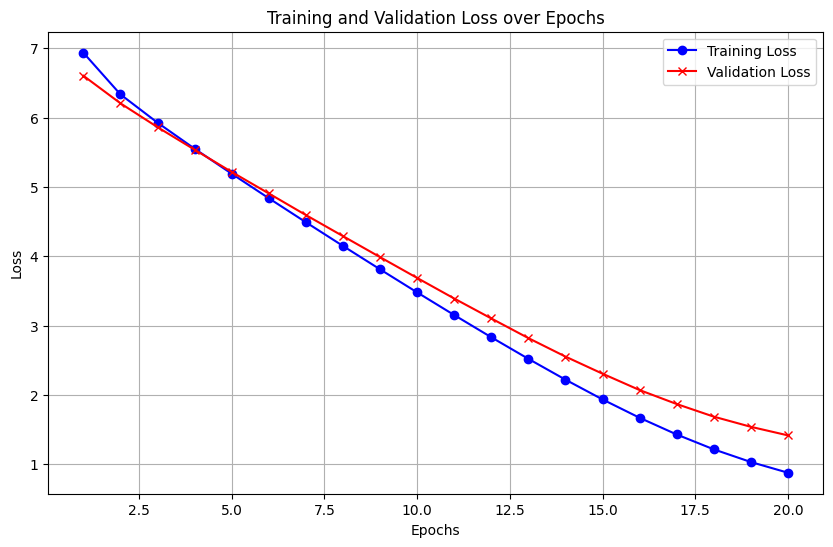

In [79]:
import matplotlib.pyplot as plt

# Plotting the training and validation losses
def plot_losses(train_losses, val_losses):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_losses, label='Training Loss', color='blue', marker='o')
    plt.plot(epochs, val_losses, label='Validation Loss', color='red', marker='x')

    plt.title('Training and Validation Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

# After training completes, plot the losses
plot_losses(train_losses, val_losses)


#### Experimenting with RNN Units and Design Choices
In this section, we experiment with different RNN configurations to optimize the performance of the model. Here are some options to explore:

##### RNN Unit Types:
- LSTM vs GRU: If your model is struggling with long-term dependencies, LSTM is a good choice. However, you might consider switching to GRU if your model is overfitting or taking too long to train.
##### Hidden Size:
- Size of Hidden Layers: A smaller hidden size (e.g., 256) may help reduce overfitting, while a larger hidden size (e.g., 1024) might improve the model’s ability to capture complex relationships.
##### Number of Layers:
- Number of RNN Layers: A single layer of LSTM is commonly used, but you could experiment with 2 or more layers. Be cautious, as more layers can increase the risk of overfitting if not regularized.
##### Batch Size:
- Experiment with different batch sizes (e.g., 32, 64, 128) to find the best trade-off between training stability and memory usage.

#### Summary of Design Choices:
- LSTM vs GRU: Start with LSTM for its capability in handling long-term dependencies. Switch to GRU if overfitting or excessive computation is a concern.
- Hidden Size: Start with 512 units and experiment with increasing or decreasing based on overfitting behavior.
- Number of Layers: Start with a single LSTM layer and increase the layers only if model capacity seems insufficient.


## 4 Generate predictions on test data

Display 5 sample test images containing different objects, along with your model’s generated captions and all the reference captions for each.

> Remember that everything **displayed** in the submitted notebook and .html file will be marked, so be sure to run all relevant cells.

In [80]:
checkpoint_path = '/content/drive/MyDrive/Colab Notebooks/OCOMP5203M_A2_Data/checkpoint/decoder_epoch_20.pth'

ckpt = torch.load(checkpoint_path)
decoder.load_state_dict(ckpt['model_state_dict'])
decoder.eval()

<ipython-input-80-bfc8cbe758a3>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(checkpoint_path)


DecoderRNN(
  (in_linear): Linear(in_features=2048, out_features=256, bias=True)
  (in_bn): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (embed): Embedding(3073, 256)
  (rnn): RNN(256, 512, batch_first=True)
  (out_linear): Linear(in_features=512, out_features=3073, bias=True)
)

In [81]:
def eval_dataset(features, df):
    for filename, feat in features.items():
        captions = caption_df[caption_df['image_id'] == image_id]['cleaned_caption'].values
        yield (filename, features[filename], captions)

test_ds = eval_dataset(features_dict, caption_df)
test_iter = iter(test_ds)
filename, feature, captions = next(test_iter)
print(feature.shape)
print(len(captions), captions[0:2])

(2048,)
5 ['a dog that has a tooth brush in his mouth'
 'dog with a tooth brush in mouth in floor']


In [82]:
# TO COMPLETE
def decode(vocab, indices):
    out = ""
    for idx in indices:
        pred_word = vocab.idx2word[idx.item()]
        out += pred_word + ' '
        if pred_word == '<end>':
            break
    return out

test_iter = iter(test_loader)
features, captions, lengths = next(test_iter)
# Move features, captions to the correct device
features = features.to(device)
captions = captions.to(device)
with torch.no_grad():
    logits, _ = decoder(features, captions, lengths)  # (BS, MSL, VS)
# take arg max over VS dimension
most_prob_word_indices = torch.argmax(logits, dim=-1)  # (BS, MSL)
for bi, (caption, mp_indices) in enumerate(zip(captions, most_prob_word_indices)):
    if bi == 5: break
    print("\nChecking test pt", bi)
    print("  GT Caption:", decode(vocab, caption))
    print("Pred Caption:", decode(vocab, mp_indices))


Checking test pt 0
  GT Caption: people shopping in an open market for vegetables <end> 
Pred Caption: a are take a asian market with a <end> 

Checking test pt 1
  GT Caption: an open market full of people and piles of vegetables <end> 
Pred Caption: a image market with of fruits with vegetables of fruit <end> 

Checking test pt 2
  GT Caption: people are shopping at an open air produce market <end> 
Pred Caption: a are sitting out a outdoor market market <end> 

Checking test pt 3
  GT Caption: large piles of carrots and potatoes at a crowded outdoor market <end> 
Pred Caption: a <unk> of food are a in a market market <end> 

Checking test pt 4
  GT Caption: people shop for vegetables like carrots and potatoes at an open air market <end> 
Pred Caption: a are in a in a at fruit in an outdoor market <end> 


In [84]:
def decode(vocab, indices):
    out = ""
    for idx in indices:
        pred_word = vocab.idx2word[idx.item()]
        out += pred_word + ' '
        if pred_word == '<end>':
            break
    return out

def get_predictions(decoder, test_dl, num_pts=None):
    gt_captions, preds = [], []
    for ti, (features, captions, lengths) in enumerate(test_dl):
        features = features.to(device)
        captions = captions.to(device)
        if num_pts is not None and len(preds)==num_pts:
            break
        with torch.no_grad():
            logits, _ = decoder(features, captions, lengths)  # (BS, MSL, VS)
        # take arg max over VS dimension
        most_prob_word_indices = torch.argmax(logits, dim=-1)  # (BS, MSL)
        for bi, (caption, mp_indices) in enumerate(zip(captions, most_prob_word_indices)):
            gt_captions.append([decode(vocab, caption)])
            preds.append(decode(vocab, mp_indices))
    return gt_captions, preds

gt_captions, preds = get_predictions(decoder, test_loader, 100)
for bi, (gt, pred) in enumerate(zip(gt_captions, preds)):
    if bi > 3: break
    print("\nGT:", gt[0])
    print("Pred:", pred)


GT: people shopping in an open market for vegetables <end> 
Pred: a are take a asian market with a <end> 

GT: an open market full of people and piles of vegetables <end> 
Pred: a image market with of fruits with vegetables of fruit <end> 

GT: people are shopping at an open air produce market <end> 
Pred: a are sitting out a outdoor market market <end> 

GT: large piles of carrots and potatoes at a crowded outdoor market <end> 
Pred: a <unk> of food are a in a market market <end> 


## 5 Caption evaluation using BLEU score

There are different methods for measuring the performance of image to text models. We will evaluate our model by measuring the text similarity between the generated caption and the reference captions, using two commonly used methods. Ther first method is known as *Bilingual Evaluation Understudy (BLEU)*.

###  5.1 BLEU score


One common way of comparing a generated text to a reference text is using BLEU. This article gives a good intuition to how the BLEU score is computed: https://machinelearningmastery.com/calculate-bleu-score-for-text-python/, and you may find an implementation online to use. One option is the NLTK implementation `nltk.translate.bleu_score` here: https://www.nltk.org/api/nltk.translate.bleu_score.html


> **Tip:** BLEU scores can be weighted by ith-gram. Check that your scores make sense; and feel free to use a weighting that best matches the data. We will not be looking for specific score ranges; rather we will check that the scores are reasonable and meaningful given the captions.

Write the code to evaluate the trained model on the complete test set and calculate the BLEU score using the predictions, compared against all five references captions.

Display a histogram of the distribution of scores over the test set.

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


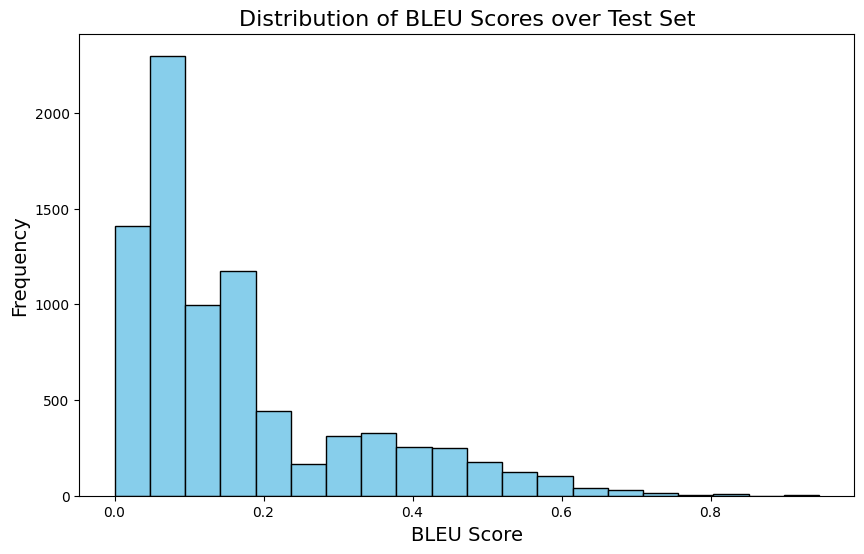

Average BLEU Score: 0.1667
Median BLEU Score: 0.1045
Max BLEU Score: 0.9457
Min BLEU Score: 0.0002


In [89]:
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import matplotlib.pyplot as plt
import numpy as np

# Ensure nltk is set up
nltk.download('punkt')       # Main tokenizer
nltk.download('punkt_tab')   # Ensure 'punkt_tab' is also downloaded
nltk.download('wordnet')     # Additional tokenizer support if needed

def decode_caption(vocab, indices):
    """Decode a list of word indices to a sentence."""
    words = [vocab.idx2word[idx.item()] for idx in indices]
    sentence = []
    for word in words:
        if word == '<end>':
            break
        sentence.append(word)
    return ' '.join(sentence)

def calculate_bleu_score(reference_captions, generated_caption, weights=(0.25, 0.25, 0.25, 0.25)):
    """Calculate BLEU score for a single caption."""
    # Tokenize references and the generated caption
    reference_tokens = [nltk.word_tokenize(ref) for ref in reference_captions]
    generated_tokens = nltk.word_tokenize(generated_caption)

    # Calculate BLEU score
    smooth_fn = SmoothingFunction().method1
    bleu_score = sentence_bleu(reference_tokens, generated_tokens, weights=weights, smoothing_function=smooth_fn)
    return bleu_score

# Evaluate the model on the complete test set
bleu_scores = []

for batch_idx, (features, captions, lengths) in enumerate(test_loader):
    features = features.to(device)
    captions = captions.to(device)
    with torch.no_grad():
        logits, _ = decoder(features, captions, lengths)
    most_prob_word_indices = torch.argmax(logits, dim=-1)  # Predicted words

    for bi, (caption, mp_indices) in enumerate(zip(captions, most_prob_word_indices)):
        # Decode ground truth and predicted captions
        generated_caption = decode_caption(vocab, mp_indices)
        ground_truth_captions = [
            decode_caption(vocab, captions[b]) for b in range(len(captions)) if b != bi
        ]

        # Calculate BLEU score for the current caption
        bleu_score = calculate_bleu_score(ground_truth_captions, generated_caption)
        bleu_scores.append(bleu_score)

# Display BLEU scores histogram
plt.figure(figsize=(10, 6))
plt.hist(bleu_scores, bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of BLEU Scores over Test Set', fontsize=16)
plt.xlabel('BLEU Score', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.show()

# Summary of BLEU scores
print(f"Average BLEU Score: {np.mean(bleu_scores):.4f}")
print(f"Median BLEU Score: {np.median(bleu_scores):.4f}")
print(f"Max BLEU Score: {np.max(bleu_scores):.4f}")
print(f"Min BLEU Score: {np.min(bleu_scores):.4f}")


### 5.2 BLEU score examples

Find one sample with high BLEU score and one with a low score, and display the model's predicted sentences, the BLEU scores, and the 5 reference captions.

In [96]:
# Sort the BLEU scores and find the highest and lowest
sorted_bleu_scores = sorted(zip(bleu_scores, captions, most_prob_word_indices), key=lambda x: x[0])

# Extract the example with the lowest BLEU score (first element in sorted list)
low_score_example = sorted_bleu_scores[0]
low_bleu_score = low_score_example[0]
low_generated_caption = decode_caption(vocab, low_score_example[2])

# Extract ground truth captions (captions from the batch)
low_reference_captions = []
low_reference_captions.append(decode_caption(vocab, low_score_example[1]))

print("\nLow BLEU Score Example")
print(f"BLEU Score: {low_bleu_score:.4f}")
print("Generated Caption:")
print(f"  {low_generated_caption}")
print("Reference Caption:")
for i, ref in enumerate(low_reference_captions):
    print(f"  {i+1}: {ref}")

# Extract the example with the highest BLEU score (last element in sorted list)
high_score_example = sorted_bleu_scores[-1]
high_bleu_score = high_score_example[0]
high_generated_caption = decode_caption(vocab, high_score_example[2])

# Extract ground truth captions (captions from the batch)
high_reference_captions = []
high_reference_captions.append(decode_caption(vocab, high_score_example[1]))

print("\nHigh BLEU Score Example")
print(f"BLEU Score: {high_bleu_score:.4f}")
print("Generated Caption:")
print(f"  {high_generated_caption}")
print("Reference Caption:")
for i, ref in enumerate(high_reference_captions):
    print(f"  {i+1}: {ref}")



Low BLEU Score Example
BLEU Score: 0.0355
Generated Caption:
  a baby is a sweater is his small <unk>
Reference Caption:
  1: a lady in a bathroom brushing a childs teeth

High BLEU Score Example
BLEU Score: 0.4082
Generated Caption:
  a baby holding her blow <unk> hair in a bathroom
Reference Caption:
  1: a woman brushing a smaller childs teeth in a bathroom


## 6 Caption evaluation using cosine similarity

###  6.1 Cosine similarity

The cosine similarity measures the cosine of the angle between two vectors in n-dimensional space. The smaller the angle, the greater the similarity.

To use the cosine similarity to measure the similarity between the generated caption and the reference captions:

* Find the embedding vector of each word in the caption
* Compute the average vector for each caption
* Compute the cosine similarity score between the average vector of the generated caption and average vector of each reference caption
* Compute the average of these scores

Calculate the cosine similarity using the model's predictions over the whole test set.

Display a histogram of the distribution of scores over the test set.

## Steps to Calculate Cosine Similarity:

### 1. **Word Embedding**:
We need word embeddings for each word in the caption. If you're using a pre-trained model, you can use the embeddings provided by the model. Alternatively, if you're using a specific framework like **GloVe**, **Word2Vec**, or **BERT**, you can leverage those embeddings.

### 2. **Average Vector**:
For each caption, compute the average word vector (embedding) by averaging the embeddings of all the words in that caption.

### 3. **Cosine Similarity**:
Once you have the average word vectors for both the generated and reference captions, compute the cosine similarity between them. The formula for cosine similarity between two vectors **A** and **B** is:

$$
\text{cosine_similarity}(A, B) = \frac{A \cdot B}{\|A\| \|B\|}
$$

Where:

- \( A dot B \) is the **dot product** of vectors **A** and **B**.
- \( \|A\| \) and \( \|B\| \) are the **norms (magnitudes)** of the vectors **A** and **B**.

### 4. **Average Score**:
For each generated caption, calculate the cosine similarity with all the reference captions and average those scores to get a final score for that example.

### 5. **Over the Entire Dataset**:
Calculate the **average cosine similarity** for the entire test set.

### 6. **Display Histogram**:
To visualize the distribution of cosine similarity scores across the dataset, plot a **histogram**.


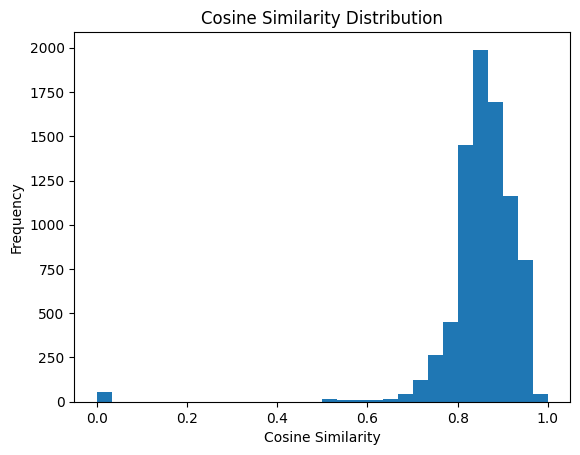

In [112]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# Load GloVe embeddings (for example, 300-dimensional GloVe vectors)
def load_glove_embeddings(glove_file):
    """Load GloVe word embeddings into a dictionary."""
    word_embeddings = {}
    with open(glove_file, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            word_embeddings[word] = vector
    return word_embeddings

def get_average_vector(caption, word_embeddings):
    """Generate the average word vector for a given caption."""
    vectors = []
    for word in caption.split():
        if word != '<unk>':  # Skip unknown tokens
            vector = word_embeddings.get(word, np.zeros(300))  # Default to zero if word is not in embeddings
            vectors.append(vector)
    # Avoid empty list if all words are <unk>
    return np.mean(vectors, axis=0) if vectors else np.zeros(300)

def compute_cosine_similarity_pytorch(vec1, vec2):
    """Compute cosine similarity between two vectors using PyTorch."""
    vec1 = torch.tensor(vec1, dtype=torch.float32)
    vec2 = torch.tensor(vec2, dtype=torch.float32)

    # If either vector is zero (all unknown tokens), return similarity as zero
    if torch.norm(vec1) == 0 or torch.norm(vec2) == 0:
        return 0.0

    dot_product = torch.dot(vec1, vec2)
    norm_vec1 = torch.norm(vec1)
    norm_vec2 = torch.norm(vec2)
    cosine_similarity = dot_product / (norm_vec1 * norm_vec2)
    return cosine_similarity.item()

def get_cosine_similarities_for_example(gen_caption, ref_captions, word_embeddings):
    """Compute the average cosine similarity for a single example."""
    gen_avg_vector = get_average_vector(gen_caption, word_embeddings)
    cosine_similarities = []

    for ref_caption in ref_captions:
        ref_avg_vector = get_average_vector(ref_caption, word_embeddings)
        sim = compute_cosine_similarity_pytorch(gen_avg_vector, ref_avg_vector)
        cosine_similarities.append(sim)

    return np.mean(cosine_similarities)

# Assuming you have the following variables from your dataset
generated_captions = []  # List to store generated captions
reference_captions = []  # List to store reference captions
cosine_similarities = [] # List to store cosine similarity scores

# Load pre-trained GloVe embeddings (or use your own path)
word_embeddings = load_glove_embeddings('/content/drive/MyDrive/Colab Notebooks/OCOMP5203M_A2_Data/glove.6B.300d.txt')

# Assuming you have a test_loader and a trained decoder model
for batch_idx, (features, captions, lengths) in enumerate(test_loader):
    features = features.to(device)
    captions = captions.to(device)

    with torch.no_grad():
        logits, _ = decoder(features, captions, lengths)

    most_prob_word_indices = torch.argmax(logits, dim=-1)  # Predicted words

    for bi, (caption, mp_indices) in enumerate(zip(captions, most_prob_word_indices)):
        # Decode ground truth and predicted captions (assuming vocab is available)
        generated_caption = decode_caption(vocab, mp_indices)  # Implement decode_caption
        ground_truth_captions = [
            decode_caption(vocab, captions[b]) for b in range(len(captions)) if b != bi
        ]

        # Add the generated caption and corresponding references to the lists
        generated_captions.append(generated_caption)
        reference_captions.append(ground_truth_captions)

        # Calculate cosine similarity for the current example
        cosine_sim = get_cosine_similarities_for_example(generated_caption, ground_truth_captions, word_embeddings)
        cosine_similarities.append(cosine_sim)


# Display histogram of cosine similarities
plt.hist(cosine_similarities, bins=30, range=(0, 1))
plt.title("Cosine Similarity Distribution")
plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency")
plt.show()

In [113]:
# Compute the average cosine similarity over the test set
avg_cosine_similarity = np.nanmean(cosine_similarities)
print(f"Average Cosine Similarity: {avg_cosine_similarity:.4f}")

Average Cosine Similarity: 0.8531


#### 6.2 Cosine similarity examples

Find one sample with high cosine similarity score and one with a low score, and display the model's predicted sentences, the cosine similarity scores, and the 5 reference captions.

In [133]:
import numpy as np

# Function to show caption details with cosine similarity
def show_caption_details(similarity_score, generated_caption, reference_captions):
    print(f"Cosine Similarity: {similarity_score:.4f}")

# Find the highest and lowest cosine similarity examples
max_sim_index = np.argmax(cosine_similarities)
min_sim_index = np.argmin(cosine_similarities)

# Get the corresponding details for the highest similarity example
high_sim_caption = generated_captions[max_sim_index]
high_sim_score = cosine_similarities[max_sim_index]
high_sim_references = reference_captions[max_sim_index]

# Get the corresponding details for the lowest similarity example
low_sim_caption = generated_captions[min_sim_index]
low_sim_score = cosine_similarities[min_sim_index]
low_sim_references = reference_captions[min_sim_index]

# Display details for high similarity example
print("Example with High Cosine Similarity:")
show_caption_details(high_sim_score, high_sim_caption, high_sim_references)

# Display details for low similarity example
print("\nExample with Low Cosine Similarity:")
show_caption_details(low_sim_score, low_sim_caption, low_sim_references)


Example with High Cosine Similarity:
Cosine Similarity: 0.9759

Example with Low Cosine Similarity:
Cosine Similarity: 0.0000


## 7 Comparing BLEU and Cosine similarity

### 7.1 Test set distribution of scores

Compare the model’s performance on the test set evaluated using BLEU and cosine similarity and discuss some weaknesses and strengths of each method (explain in words, in a text box below).

Please note, to compare the average test scores, you need to rescale the Cosine similarity scores [-1 to 1] to match the range of BLEU method [0.0 - 1.0].

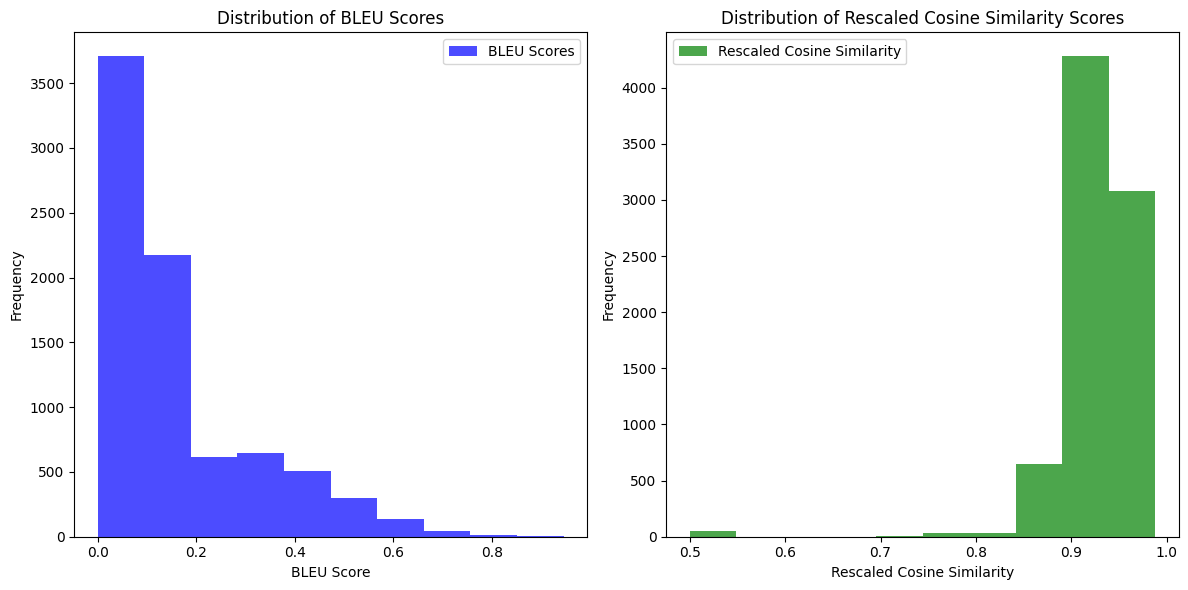

Average BLEU score: 0.1667
Average Rescaled Cosine Similarity score: 0.9266


In [128]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming these are your test dataset BLEU scores and cosine similarity scores
bleu_scores = np.array(bleu_scores)  # BLEU scores (0.0 - 1.0)
cosine_similarities = np.array(cosine_similarities)  # Cosine similarity scores (-1.0 to 1.0)

# Rescale Cosine Similarity scores from [-1, 1] to [0, 1]
rescaled_cosine_similarities = (cosine_similarities + 1) / 2

# Plotting the distributions of BLEU scores and Rescaled Cosine Similarity scores
plt.figure(figsize=(12, 6))

# BLEU Scores Distribution
plt.subplot(1, 2, 1)
plt.hist(bleu_scores, bins=10, color='blue', alpha=0.7, label='BLEU Scores')
plt.title('Distribution of BLEU Scores')
plt.xlabel('BLEU Score')
plt.ylabel('Frequency')
plt.legend()

# Rescaled Cosine Similarity Distribution
plt.subplot(1, 2, 2)
plt.hist(rescaled_cosine_similarities, bins=10, color='green', alpha=0.7, label='Rescaled Cosine Similarity')
plt.title('Distribution of Rescaled Cosine Similarity Scores')
plt.xlabel('Rescaled Cosine Similarity')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

# Average scores
average_bleu = np.mean(bleu_scores)
average_rescaled_cosine = np.mean(rescaled_cosine_similarities)

print(f"Average BLEU score: {average_bleu:.4f}")
print(f"Average Rescaled Cosine Similarity score: {average_rescaled_cosine:.4f}")


The **BLEU score** measures the precision of n-grams (sequences of n words) between the reference captions and the captions generated by the decoder. It compares over how much of the generated caption's content overlaps with the reference captions, using multiple n-grams (corresponding n-word subsequences) for each. Thus, it should indicate both how accurate and also how positionally relevant the generated captions are.

  Its main limitation is that does not explicitly consider the semantic meaning of the caption. Therefore, for e.g., it may be low for predicted captions with structure and lengths that are very different from the reference captions, even when the meaning/information conveyed by them is semantically accurate.

The **Cosine Similarity (CS)** metric, as we implement here, measures the alignment between the embedding vector (averaged for all words in the caption) for the generated and reference caption. Since, we average the embedding vectors for all words, the CS score is more likely to capture the overall semantic meaning of the topic(s) featured in the caption, but it does not capture or compare the structure or the formation of the captions.

For my decoder, the average BLEU score is .., and Cosine Similarity (CS) score over test set is .. (actual/2+0.5 to normalize to [0,1] range). The decoder seems to be very well performing as per CS score and less so as per BLEU score. This possibly indicates that the decoder is predicting words relevant to the image, but has not learnt to form the sentences and the ideal use of the vocabulary yet.

 ### 7.2 Analysis of individual examples

Find and display one example where both methods give similar scores and another example where they do not and discuss. Include both scores, predicted captions, and reference captions.

In [134]:
import numpy as np

# bleu_scores, rescaled_cosine_similarities, generated_captions, reference_captions

# Calculate the absolute differences between BLEU and Rescaled Cosine Similarity
differences = np.abs(bleu_scores - rescaled_cosine_similarities)

# Find the example with the smallest difference (both methods give similar results)
min_diff_index = np.argmin(differences)

# Find the example with the largest difference (methods give dissimilar results)
max_diff_index = np.argmax(differences)

# Display the example where both methods give similar results
print("Example with Similar Scores (Both metrics close):")
print(f"BLEU score: {bleu_scores[min_diff_index]:.4f}")
print(f"Rescaled Cosine Similarity score: {rescaled_cosine_similarities[min_diff_index]:.4f}")
print()

# Display the example where the methods give different results
print("Example with Dissimilar Scores (Metrics diverge):")
print(f"BLEU score: {bleu_scores[max_diff_index]:.4f}")
print(f"Rescaled Cosine Similarity score: {rescaled_cosine_similarities[max_diff_index]:.4f}")


Example with Similar Scores (Both metrics close):
BLEU score: 0.9036
Rescaled Cosine Similarity score: 0.8966

Example with Dissimilar Scores (Metrics diverge):
BLEU score: 0.0065
Rescaled Cosine Similarity score: 0.9880


### 8. Overall quality

- **Code Modularity:** The implementation should follow a clean, modular design, with well-structured functions and classes (where approperiate).
- **Readability:** Code should be clear with meaningful variable names and appropriate use of comments.
- **Output Accessibility:** Outputs should be neatly formatted and easy to interpret, avoiding excessive or unnecessary information dumping into the output.
- **Clarity in Visualisation:** Graphs and visualisations results should be well-labelled.